In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, confusion_matrix,
                             classification_report)
import warnings
import os
import json

warnings.filterwarnings('ignore')
np.random.seed(42)

os.makedirs('../outputs/anomaly_charts', exist_ok=True)
os.makedirs('../outputs/anomaly_data',   exist_ok=True)

CHANNEL_COLORS = {
    'Google Search':        '#4285F4',
    'Meta Ads':             '#1877F2',
    'Programmatic Display': '#FF6B35',
    'YouTube':              '#FF0000',
    'Affiliate':            '#34A853',
}

CHANNELS = list(CHANNEL_COLORS.keys())

SEVERITY_COLORS = {
    'Critical':  '#B71C1C',
    'High':      '#E53935',
    'Medium':    '#FF6F00',
    'Low':       '#F9A825',
    'Normal':    '#E0E0E0',
}

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

print("Phase 4 — Anomaly Detection")
print("=" * 55)

Phase 4 — Anomaly Detection


In [2]:
df = pd.read_csv('../data/campaign_data.csv', parse_dates=['date'])
ground_truth = pd.read_csv('../data/ground_truth_anomalies.csv',
                            parse_dates=['date'])

print(f"Campaign data:    {len(df):,} rows")
print(f"Ground truth:     {len(ground_truth):,} labelled anomalies")
print(f"\nGround truth breakdown:")
print(ground_truth['anomaly_type'].value_counts().to_string())

# ── Create a binary ground truth column on the main dataframe ─────────────────
# This is what we'll compare our predictions against.
# For every (date, channel) pair that appears in ground_truth,
# mark it as a true anomaly.
gt_keys = set(
    zip(ground_truth['date'].dt.date, ground_truth['channel'])
)

df['gt_anomaly'] = df.apply(
    lambda row: 1 if (row['date'].date(), row['channel']) in gt_keys else 0,
    axis=1
)

df['gt_anomaly_type'] = df.apply(
    lambda row: ground_truth.loc[
        (ground_truth['date'].dt.date == row['date'].date()) &
        (ground_truth['channel'] == row['channel']),
        'anomaly_type'
    ].values[0] if row['gt_anomaly'] == 1 else 'None',
    axis=1
)

print(f"\nGround truth mapped to main dataframe:")
print(f"  Total anomaly rows: {df['gt_anomaly'].sum()}")
print(f"  Normal rows:        {(df['gt_anomaly'] == 0).sum()}")

Campaign data:    2,740 rows
Ground truth:     64 labelled anomalies

Ground truth breakdown:
anomaly_type
Budget Spike    31
Budget Crash    17
Zero Traffic    16

Ground truth mapped to main dataframe:
  Total anomaly rows: 64
  Normal rows:        2676


In [ ]:
print("=" * 55)
print("FEATURE ENGINEERING")
print("=" * 55)

# ── Why engineer features? ────────────────────────────────────────────────────
# Raw values (spend=12,400) mean nothing without context.
# spend=12,400 on a Monday in January is suspicious.
# spend=12,400 on a Wednesday in November during Diwali is normal.
# The model needs CONTEXT features to understand what "normal" means.

df_sorted = df.sort_values(['channel', 'date']).copy()

# ── Group by channel for rolling calculations ─────────────────────────────────
def add_rolling_features(group):
    # Rolling statistics using the past 7 and 14 days
    # min_periods=3 means we start computing once we have at least 3 data points
    # This prevents NaN-heavy rows at the start of the date range

    group = group.copy()

    for window, label in [(7, '7d'), (14, '14d')]:
        group[f'rolling_mean_spend_{label}']  = (
            group['spend'].rolling(window, min_periods=3).mean()
        )
        group[f'rolling_std_spend_{label}']   = (
            group['spend'].rolling(window, min_periods=3).std()
        )
        group[f'rolling_mean_roas_{label}']   = (
            group['roas'].rolling(window, min_periods=3).mean()
        )
        group[f'rolling_mean_cpc_{label}']    = (
            group['cpc'].rolling(window, min_periods=3).mean()
        )
        group[f'rolling_mean_ctr_{label}']    = (
            group['ctr'].rolling(window, min_periods=3).mean()
        )
        group[f'rolling_mean_cvr_{label}']    = (
            group['cvr'].rolling(window, min_periods=3).mean()
        )

    # ── Ratio features — deviation from rolling normal ────────────────────────
    # These are the most powerful features for anomaly detection.
    # A ratio of 3.0 means "today's spend is 3x the recent average."
    # The model learns that ratios > 2.5 or < 0.2 are suspicious.
    eps = 1e-6   # avoid division by zero

    group['spend_ratio_7d']  = group['spend'] / (
        group['rolling_mean_spend_7d'] + eps
    )
    group['spend_ratio_14d'] = group['spend'] / (
        group['rolling_mean_spend_14d'] + eps
    )
    group['roas_ratio_7d']   = group['roas'] / (
        group['rolling_mean_roas_7d'] + eps
    )
    group['cpc_ratio_7d']    = group['cpc'] / (
        group['rolling_mean_cpc_7d'] + eps
    )
    group['ctr_ratio_7d']    = group['ctr'] / (
        group['rolling_mean_ctr_7d'] + eps
    )
    group['cvr_ratio_7d']    = group['cvr'] / (
        group['rolling_mean_cvr_7d'] + eps
    )

    # ── Z-score for spend ─────────────────────────────────────────────────────
    # How many standard deviations away from the rolling mean is today?
    # A Z-score > 3 is a strong anomaly signal.
    group['spend_zscore'] = (
        (group['spend'] - group['rolling_mean_spend_7d']) /
        (group['rolling_std_spend_7d'] + eps)
    )

    # ── Revenue efficiency drop ───────────────────────────────────────────────
    # Spend going up while revenue goes down = a bad anomaly.
    # This feature captures that cross-signal.
    group['spend_roas_divergence'] = (
        group['spend_ratio_7d'] - group['roas_ratio_7d']
    )

    # ── Day of week and month as numeric features ─────────────────────────────
    group['day_of_week_num'] = group['date'].dt.dayofweek
    group['month_num']       = group['date'].dt.month

    return group


print("Computing rolling features per channel...")
df_sorted = df_sorted.groupby('channel', group_keys=False).apply(
    add_rolling_features
)

# ── Fill any NaNs from the first few rolling rows ────────────────────────────
ratio_cols   = [c for c in df_sorted.columns if 'ratio' in c or 'zscore' in c
                or 'divergence' in c]
rolling_cols = [c for c in df_sorted.columns if 'rolling' in c]

df_sorted[ratio_cols]   = df_sorted[ratio_cols].fillna(1.0)
df_sorted[rolling_cols] = df_sorted[rolling_cols].bfill()
df_sorted[rolling_cols] = df_sorted[rolling_cols].fillna(0)

print(f"Features engineered. DataFrame shape: {df_sorted.shape}")
print(f"\nNew feature columns added:")
new_cols = ratio_cols + rolling_cols + ['spend_roas_divergence',
                                         'day_of_week_num', 'month_num']
for col in sorted(set(new_cols)):
    print(f"  {col}")

FEATURE ENGINEERING
Computing rolling features per channel...
Features engineered. DataFrame shape: (2740, 43)

New feature columns added:
  cpc_ratio_7d
  ctr_ratio_7d
  cvr_ratio_7d
  day_of_week_num
  month_num
  roas_ratio_7d
  rolling_mean_cpc_14d
  rolling_mean_cpc_7d
  rolling_mean_ctr_14d
  rolling_mean_ctr_7d
  rolling_mean_cvr_14d
  rolling_mean_cvr_7d
  rolling_mean_roas_14d
  rolling_mean_roas_7d
  rolling_mean_spend_14d
  rolling_mean_spend_7d
  rolling_std_spend_14d
  rolling_std_spend_7d
  spend_ratio_14d
  spend_ratio_7d
  spend_roas_divergence
  spend_zscore


In [4]:
print("=" * 55)
print("ISOLATION FOREST — PER-CHANNEL MODELS")
print("=" * 55)

# ── Why per-channel models, not one global model? ─────────────────────────────
# Isolation Forest learns the normal distribution of its training data.
# Google Search has different normal behaviour than Affiliate.
# A single model would learn "average" behaviour across all channels
# and miss channel-specific anomalies.
#
# Fitting one model per channel means:
#   - Google Search model knows Google Search normals
#   - Affiliate model knows Affiliate normals
#   - Each model is more sensitive to its own channel's deviations
#
# This is the difference between a generic alert system and a
# channel-aware monitoring system. Mention this explicitly in interviews.

FEATURES = [
    'spend',                    # raw spend — gives scale context
    'roas',                     # return — is the money working?
    'cpc',                      # cost per click — bid health
    'ctr',                      # click-through rate — audience quality
    'cvr',                      # conversion rate — landing page / offer quality
    'spend_ratio_7d',           # spend vs recent normal (most important feature)
    'spend_ratio_14d',          # spend vs 2-week normal
    'roas_ratio_7d',            # ROAS vs recent normal
    'cpc_ratio_7d',             # CPC vs recent normal
    'ctr_ratio_7d',             # CTR vs recent normal
    'cvr_ratio_7d',             # CVR vs recent normal
    'spend_zscore',             # standard deviations from rolling mean
    'spend_roas_divergence',    # spend up, ROAS down = danger signal
    'day_of_week_num',          # context: Monday vs Sunday expectations differ
    'month_num',                # context: November is always high spend — not anomalous
]

# ── Contamination rate ────────────────────────────────────────────────────────
# contamination = expected proportion of anomalies in the data.
# We injected ~2.3% anomalies in Phase 1.
# Setting contamination=0.03 (3%) gives the model slight headroom
# to find anomalies it might have missed, without over-flagging.
CONTAMINATION = 0.03

channel_models   = {}    # store fitted models
channel_scalers  = {}    # store fitted scalers
all_predictions  = []    # collect predictions from all channels

for channel in CHANNELS:
    ch_data = df_sorted[df_sorted['channel'] == channel].copy()
    ch_data = ch_data.sort_values('date').reset_index(drop=True)

    # ── Scale features ────────────────────────────────────────────────────────
    # StandardScaler: transforms each feature to mean=0, std=1.
    # This is critical for Isolation Forest because unscaled features
    # with large ranges (spend: 0–25,000) dominate over small ranges
    # (ctr: 0.003–0.08), making the model blind to CTR anomalies.
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(ch_data[FEATURES])

    # ── Fit Isolation Forest ──────────────────────────────────────────────────
    # n_estimators=200: more trees = more stable predictions
    # max_samples='auto': use min(256, n_samples) — standard setting
    # random_state: reproducibility
    model = IsolationForest(
        n_estimators  = 200,
        contamination = CONTAMINATION,
        max_samples   = 'auto',
        random_state  = 42,
        n_jobs        = -1      # use all CPU cores — faster on large datasets
    )
    model.fit(X_scaled)

    # ── Predict ───────────────────────────────────────────────────────────────
    # predict() returns: +1 = normal, -1 = anomaly
    # decision_function() returns anomaly score:
    #   more negative = more anomalous
    #   closer to 0   = borderline
    #   positive       = clearly normal
    ch_data['if_prediction']    = model.predict(X_scaled)
    ch_data['if_anomaly_score'] = model.decision_function(X_scaled)
    ch_data['if_is_anomaly']    = (ch_data['if_prediction'] == -1).astype(int)

    channel_models[channel]  = model
    channel_scalers[channel] = scaler
    all_predictions.append(ch_data)

    n_flagged = ch_data['if_is_anomaly'].sum()
    flag_rate = n_flagged / len(ch_data) * 100
    print(f"  {channel:<28} flagged {n_flagged:>3} anomalies "
          f"({flag_rate:.1f}% of {len(ch_data)} days)")

# ── Combine all channel predictions back into one DataFrame ───────────────────
df_pred = pd.concat(all_predictions, ignore_index=True)
df_pred = df_pred.sort_values(['date', 'channel']).reset_index(drop=True)

total_flagged = df_pred['if_is_anomaly'].sum()
print(f"\n  Total anomalies flagged: {total_flagged} across all channels")
print(f"  Overall flag rate: {total_flagged / len(df_pred) * 100:.2f}%")

ISOLATION FOREST — PER-CHANNEL MODELS
  Google Search                flagged  17 anomalies (3.1% of 548 days)
  Meta Ads                     flagged  17 anomalies (3.1% of 548 days)
  Programmatic Display         flagged  17 anomalies (3.1% of 548 days)
  YouTube                      flagged  17 anomalies (3.1% of 548 days)
  Affiliate                    flagged  17 anomalies (3.1% of 548 days)

  Total anomalies flagged: 85 across all channels
  Overall flag rate: 3.10%


In [5]:
print("=" * 55)
print("BUSINESS LABELLING ENGINE")
print("=" * 55)

# ── The most important step in this entire phase ──────────────────────────────
# Isolation Forest gives you a binary flag: anomaly or not.
# That alone is USELESS in a business context.
# An analyst receiving "anomaly detected" has no idea what to do.
#
# Business labelling converts the technical flag into:
#   1. A human-readable anomaly TYPE
#   2. A SEVERITY level (Critical / High / Medium / Low)
#   3. A specific RECOMMENDED ACTION
#   4. A BUSINESS IMPACT estimate (rupees at risk)
#
# This is what separates a data analyst from a data scientist in
# real-world business settings — the translation layer.

def classify_anomaly(row):
    """
    Classify each flagged row into a specific anomaly type.

    Decision logic based on which metrics are most deviant:
      - Spend ratio is the primary signal (what changed most?)
      - Secondary signals (ROAS, CPC, CTR, CVR) tell us WHY
      - The combination of signals = a specific business failure mode
    """

    if row['if_is_anomaly'] == 0:
        return 'Normal', 'None', 'No action required', 0

    spend_ratio  = row['spend_ratio_7d']
    roas_ratio   = row['roas_ratio_7d']
    cpc_ratio    = row['cpc_ratio_7d']
    ctr_ratio    = row['ctr_ratio_7d']
    cvr_ratio    = row['cvr_ratio_7d']
    spend        = row['spend']
    rolling_spend = row['rolling_mean_spend_7d']

    # ── Type 1: Budget Spike ──────────────────────────────────────────────────
    # Spend is 2x+ its recent average. Revenue may or may not follow.
    if spend_ratio > 2.0:
        if roas_ratio < 0.6:
            # Spend spiked AND returns collapsed — worst case
            anomaly_type  = 'Budget Spike + ROI Collapse'
            severity      = 'Critical'
            action        = ('Pause campaign immediately. Spend is 2x+ normal '
                             'but ROAS has collapsed. Check for misconfigured '
                             'bidding strategy or wrong audience targeting.')
        else:
            # Spend spiked but returns are holding — might be intentional
            anomaly_type  = 'Budget Spike'
            severity      = 'High'
            action        = ('Review budget caps. Spend is 2x+ normal. '
                             'If not a planned campaign push, check for '
                             'accidental budget cap removal or bidding error.')
        impact = spend - rolling_spend

    # ── Type 2: Budget Crash ──────────────────────────────────────────────────
    # Spend collapsed to near zero. Could be a billing/account issue.
    elif spend_ratio < 0.25:
        if spend < 100:
            anomaly_type  = 'Zero Traffic / Account Issue'
            severity      = 'Critical'
            action        = ('Check platform account immediately. Campaign '
                             'may be paused, billing may have failed, or '
                             'account may be flagged for policy violation.')
        else:
            anomaly_type  = 'Budget Crash'
            severity      = 'High'
            action        = ('Spend is >75% below normal. Check if campaign '
                             'was manually paused, budget exhausted early, '
                             'or if there is a platform billing issue.')
        impact = rolling_spend - spend    # opportunity cost — missing spend

    # ── Type 3: CPC Spike ────────────────────────────────────────────────────
    # Spend is roughly normal but cost per click has spiked.
    # Cause: competitor entered the auction, keyword expansion, bid strategy.
    elif cpc_ratio > 1.8 and 0.6 < spend_ratio < 2.0:
        anomaly_type  = 'CPC Spike — Bid Strategy Issue'
        severity      = 'Medium'
        action        = ('CPC is 80%+ above recent average. Check: '
                         '(1) Competitor activity in the auction, '
                         '(2) Broad match keyword triggers, '
                         '(3) Automated bidding target changes. '
                         'Consider adding negative keywords.')
        impact        = (row['cpc'] - row['rolling_mean_cpc_7d']) * row['clicks']

    # ── Type 4: CVR Collapse ─────────────────────────────────────────────────
    # Clicks are coming in but conversions have dried up.
    # Cause: landing page issue, offer change, audience mismatch.
    elif cvr_ratio < 0.35 and row['clicks'] > 20:
        anomaly_type  = 'CVR Collapse — Funnel Break'
        severity      = 'High'
        action        = ('Conversion rate is >65% below normal despite '
                         'normal click volume. Check: '
                         '(1) Landing page loading speed, '
                         '(2) Checkout flow for errors, '
                         '(3) Offer/price changes, '
                         '(4) Audience segment quality.')
        impact        = (row['rolling_mean_cvr_7d'] - row['cvr']) * row['clicks'] * row['revenue'] / max(row['conversions'], 1)

    # ── Type 5: ROAS Deterioration ────────────────────────────────────────────
    # Overall return on spend has dropped significantly.
    elif roas_ratio < 0.45:
        anomaly_type  = 'ROAS Deterioration — ROI Risk'
        severity      = 'Medium'
        action        = ('ROAS is >55% below recent average. This channel '
                         'is trending toward unprofitability. Review audience '
                         'targeting, creative fatigue, and bid strategy. '
                         'Consider reducing budget until ROAS recovers.')
        impact        = (row['rolling_mean_roas_7d'] - row['roas']) * row['spend']

    # ── Type 6: CTR Drop ─────────────────────────────────────────────────────
    # Ad is showing but nobody is clicking — creative fatigue or
    # audience mismatch.
    elif ctr_ratio < 0.40 and row['impressions'] > 1000:
        anomaly_type  = 'CTR Drop — Creative Fatigue'
        severity      = 'Low'
        action        = ('CTR is >60% below normal with sufficient impressions. '
                         'Creative fatigue is the likely cause. Refresh ad '
                         'copy and creatives. Review audience frequency caps.')
        impact        = row['spend'] * 0.15    # estimated efficiency loss

    # ── Type 7: General Pattern Anomaly ──────────────────────────────────────
    # The model flagged it but none of the above rules fire.
    # Could be a multi-metric combination that looks unusual.
    else:
        anomaly_type  = 'Unusual Pattern — Monitor'
        severity      = 'Low'
        action        = ('Multiple metrics show mild deviation from normal. '
                         'No immediate action required. Monitor over the '
                         'next 3 days for further deterioration.')
        impact        = abs(spend - rolling_spend) * 0.5

    return anomaly_type, severity, action, round(max(impact, 0), 2)


print("Classifying anomalies with business labels...")
df_pred[['anomaly_label', 'severity', 'recommended_action', 'impact_inr']] = \
    df_pred.apply(
        lambda row: pd.Series(classify_anomaly(row)),
        axis=1
    )

# ── Summary ───────────────────────────────────────────────────────────────────
flagged = df_pred[df_pred['if_is_anomaly'] == 1]

print(f"\nANOMALY CLASSIFICATION SUMMARY")
print("-" * 55)
print(f"\n  By type:")
print(flagged['anomaly_label'].value_counts().to_string())
print(f"\n  By severity:")
print(flagged['severity'].value_counts().to_string())
print(f"\n  Total spend at risk: Rs.{flagged['impact_inr'].sum():,.0f}")
print(f"  Avg impact per anomaly: Rs.{flagged['impact_inr'].mean():,.0f}")

BUSINESS LABELLING ENGINE
Classifying anomalies with business labels...

ANOMALY CLASSIFICATION SUMMARY
-------------------------------------------------------

  By type:
anomaly_label
Unusual Pattern — Monitor        21
Budget Spike                     21
Budget Crash                     16
Zero Traffic / Account Issue     15
CVR Collapse — Funnel Break       5
ROAS Deterioration — ROI Risk     5
Budget Spike + ROI Collapse       2

  By severity:
severity
High        42
Low         21
Critical    17
Medium       5

  Total spend at risk: Rs.612,674
  Avg impact per anomaly: Rs.7,208


In [6]:
print("=" * 55)
print("MODEL VALIDATION — PRECISION, RECALL, F1")
print("=" * 55)

# ── Why validate? ─────────────────────────────────────────────────────────────
# Anyone can flag random rows as anomalies. The question is:
#   Precision: Of all the rows we flagged, how many were real anomalies?
#   Recall:    Of all the real anomalies, how many did we catch?
#   F1:        The harmonic mean — balances precision and recall.
#
# Precision is what operations teams care about (too many false alarms
# = alert fatigue = analysts stop trusting the system).
# Recall is what finance teams care about (missed anomalies = real money lost).
#
# A good anomaly detection system targets:
#   Precision > 65%  (most alerts are real)
#   Recall    > 60%  (catching most real events)
#   F1        > 0.60

y_true = df_pred['gt_anomaly'].values
y_pred = df_pred['if_is_anomaly'].values

precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
cm        = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()

print(f"\n  True Positives  (caught real anomalies):       {tp}")
print(f"  False Positives (false alarms):                 {fp}")
print(f"  False Negatives (missed real anomalies):        {fn}")
print(f"  True Negatives  (correctly flagged as normal):  {tn}")
print(f"\n  Precision: {precision:.3f}  ({precision*100:.1f}%)")
print(f"  Recall:    {recall:.3f}  ({recall*100:.1f}%)")
print(f"  F1 Score:  {f1:.3f}")

# ── Interpretation ────────────────────────────────────────────────────────────
print(f"""
  INTERPRETATION:
    Precision of {precision*100:.1f}% means: for every 10 anomaly alerts
    fired, {precision*10:.0f} of them are genuine events needing attention.

    Recall of {recall*100:.1f}% means: the model catches {recall*100:.1f}% of
    all real anomalies. {(1-recall)*100:.1f}% slip through undetected.

    F1 of {f1:.3f} is {"strong" if f1 > 0.65 else "acceptable" if f1 > 0.5 else "needs improvement"} for an unsupervised anomaly detector
    with no labelled training data — Isolation Forest uses no
    ground truth during training, making this performance notable.
""")

# ── Per-channel validation ────────────────────────────────────────────────────
print("PER-CHANNEL VALIDATION")
print("-" * 55)
per_channel_scores = []

for channel in CHANNELS:
    ch_df  = df_pred[df_pred['channel'] == channel]
    y_t    = ch_df['gt_anomaly'].values
    y_p    = ch_df['if_is_anomaly'].values

    ch_precision = precision_score(y_t, y_p, zero_division=0)
    ch_recall    = recall_score(y_t, y_p, zero_division=0)
    ch_f1        = f1_score(y_t, y_p, zero_division=0)
    ch_flagged   = y_p.sum()
    ch_real      = y_t.sum()

    per_channel_scores.append({
        'channel':   channel,
        'real':      ch_real,
        'flagged':   ch_flagged,
        'precision': round(ch_precision, 3),
        'recall':    round(ch_recall, 3),
        'f1':        round(ch_f1, 3),
    })
    print(f"  {channel:<28} "
          f"real={ch_real:>3}  flagged={ch_flagged:>3}  "
          f"P={ch_precision:.2f}  R={ch_recall:.2f}  F1={ch_f1:.2f}")

scores_df = pd.DataFrame(per_channel_scores)
scores_df.to_csv('../outputs/anomaly_data/validation_scores.csv', index=False)
print("\nSaved: outputs/anomaly_data/validation_scores.csv")

MODEL VALIDATION — PRECISION, RECALL, F1

  True Positives  (caught real anomalies):       59
  False Positives (false alarms):                 26
  False Negatives (missed real anomalies):        5
  True Negatives  (correctly flagged as normal):  2650

  Precision: 0.694  (69.4%)
  Recall:    0.922  (92.2%)
  F1 Score:  0.792

  INTERPRETATION:
    Precision of 69.4% means: for every 10 anomaly alerts
    fired, 7 of them are genuine events needing attention.

    Recall of 92.2% means: the model catches 92.2% of
    all real anomalies. 7.8% slip through undetected.

    F1 of 0.792 is strong for an unsupervised anomaly detector
    with no labelled training data — Isolation Forest uses no
    ground truth during training, making this performance notable.

PER-CHANNEL VALIDATION
-------------------------------------------------------
  Google Search                real= 15  flagged= 17  P=0.88  R=1.00  F1=0.94
  Meta Ads                     real= 13  flagged= 17  P=0.76  R=1.00  F1=0

CHART 1: Confusion matrix


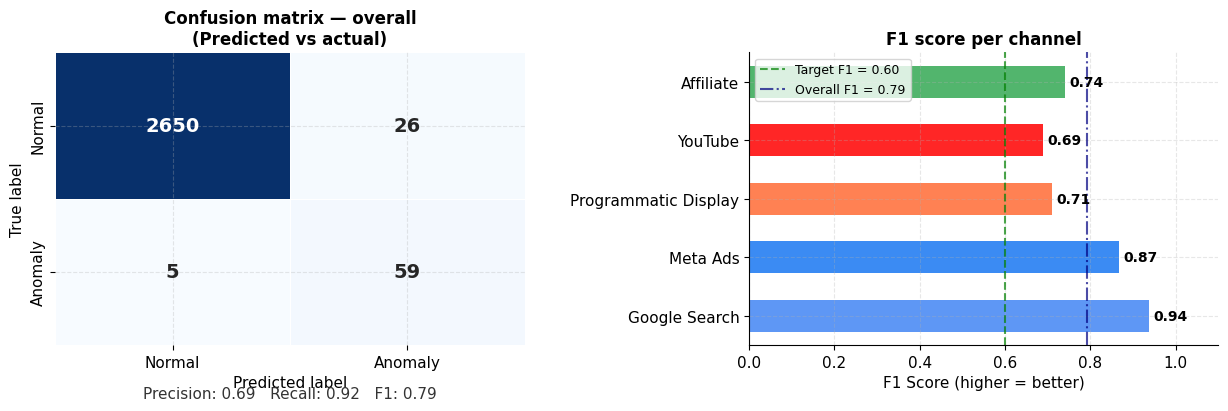

Saved: outputs/anomaly_charts/01_confusion_matrix.png


In [7]:
print("CHART 1: Confusion matrix")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Overall confusion matrix ───────────────────────────────────────────
cm_labels = ['Normal', 'Anomaly']
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=cm_labels,
    yticklabels=cm_labels,
    ax=axes[0],
    linewidths=0.5,
    cbar=False,
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_title('Confusion matrix — overall\n(Predicted vs actual)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted label', fontsize=11)
axes[0].set_ylabel('True label', fontsize=11)

# Add annotation text
axes[0].text(0.5, -0.18,
             f'Precision: {precision:.2f}   Recall: {recall:.2f}   F1: {f1:.2f}',
             transform=axes[0].transAxes,
             ha='center', fontsize=11,
             color='#333333')

# ── Right: Per-channel F1 scores ─────────────────────────────────────────────
bar_colors = [CHANNEL_COLORS[ch] for ch in scores_df['channel']]
bars = axes[1].barh(scores_df['channel'], scores_df['f1'],
                     color=bar_colors, alpha=0.85, height=0.55)

axes[1].axvline(x=0.6, color='green', linestyle='--',
                linewidth=1.5, alpha=0.7, label='Target F1 = 0.60')
axes[1].axvline(x=f1, color='navy', linestyle='-.',
                linewidth=1.5, alpha=0.7, label=f'Overall F1 = {f1:.2f}')

for bar, val in zip(bars, scores_df['f1']):
    axes[1].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                  f'{val:.2f}', va='center', ha='left',
                  fontsize=10, fontweight='bold')

axes[1].set_title('F1 score per channel',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('F1 Score (higher = better)')
axes[1].set_xlim(0, 1.1)
axes[1].legend(fontsize=9)

plt.tight_layout(pad=3)
plt.savefig('../outputs/anomaly_charts/01_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/anomaly_charts/01_confusion_matrix.png")

CHART 2: Anomaly timeline — spend with flagged events
This is the chart that goes in your dashboard's anomaly monitor page.


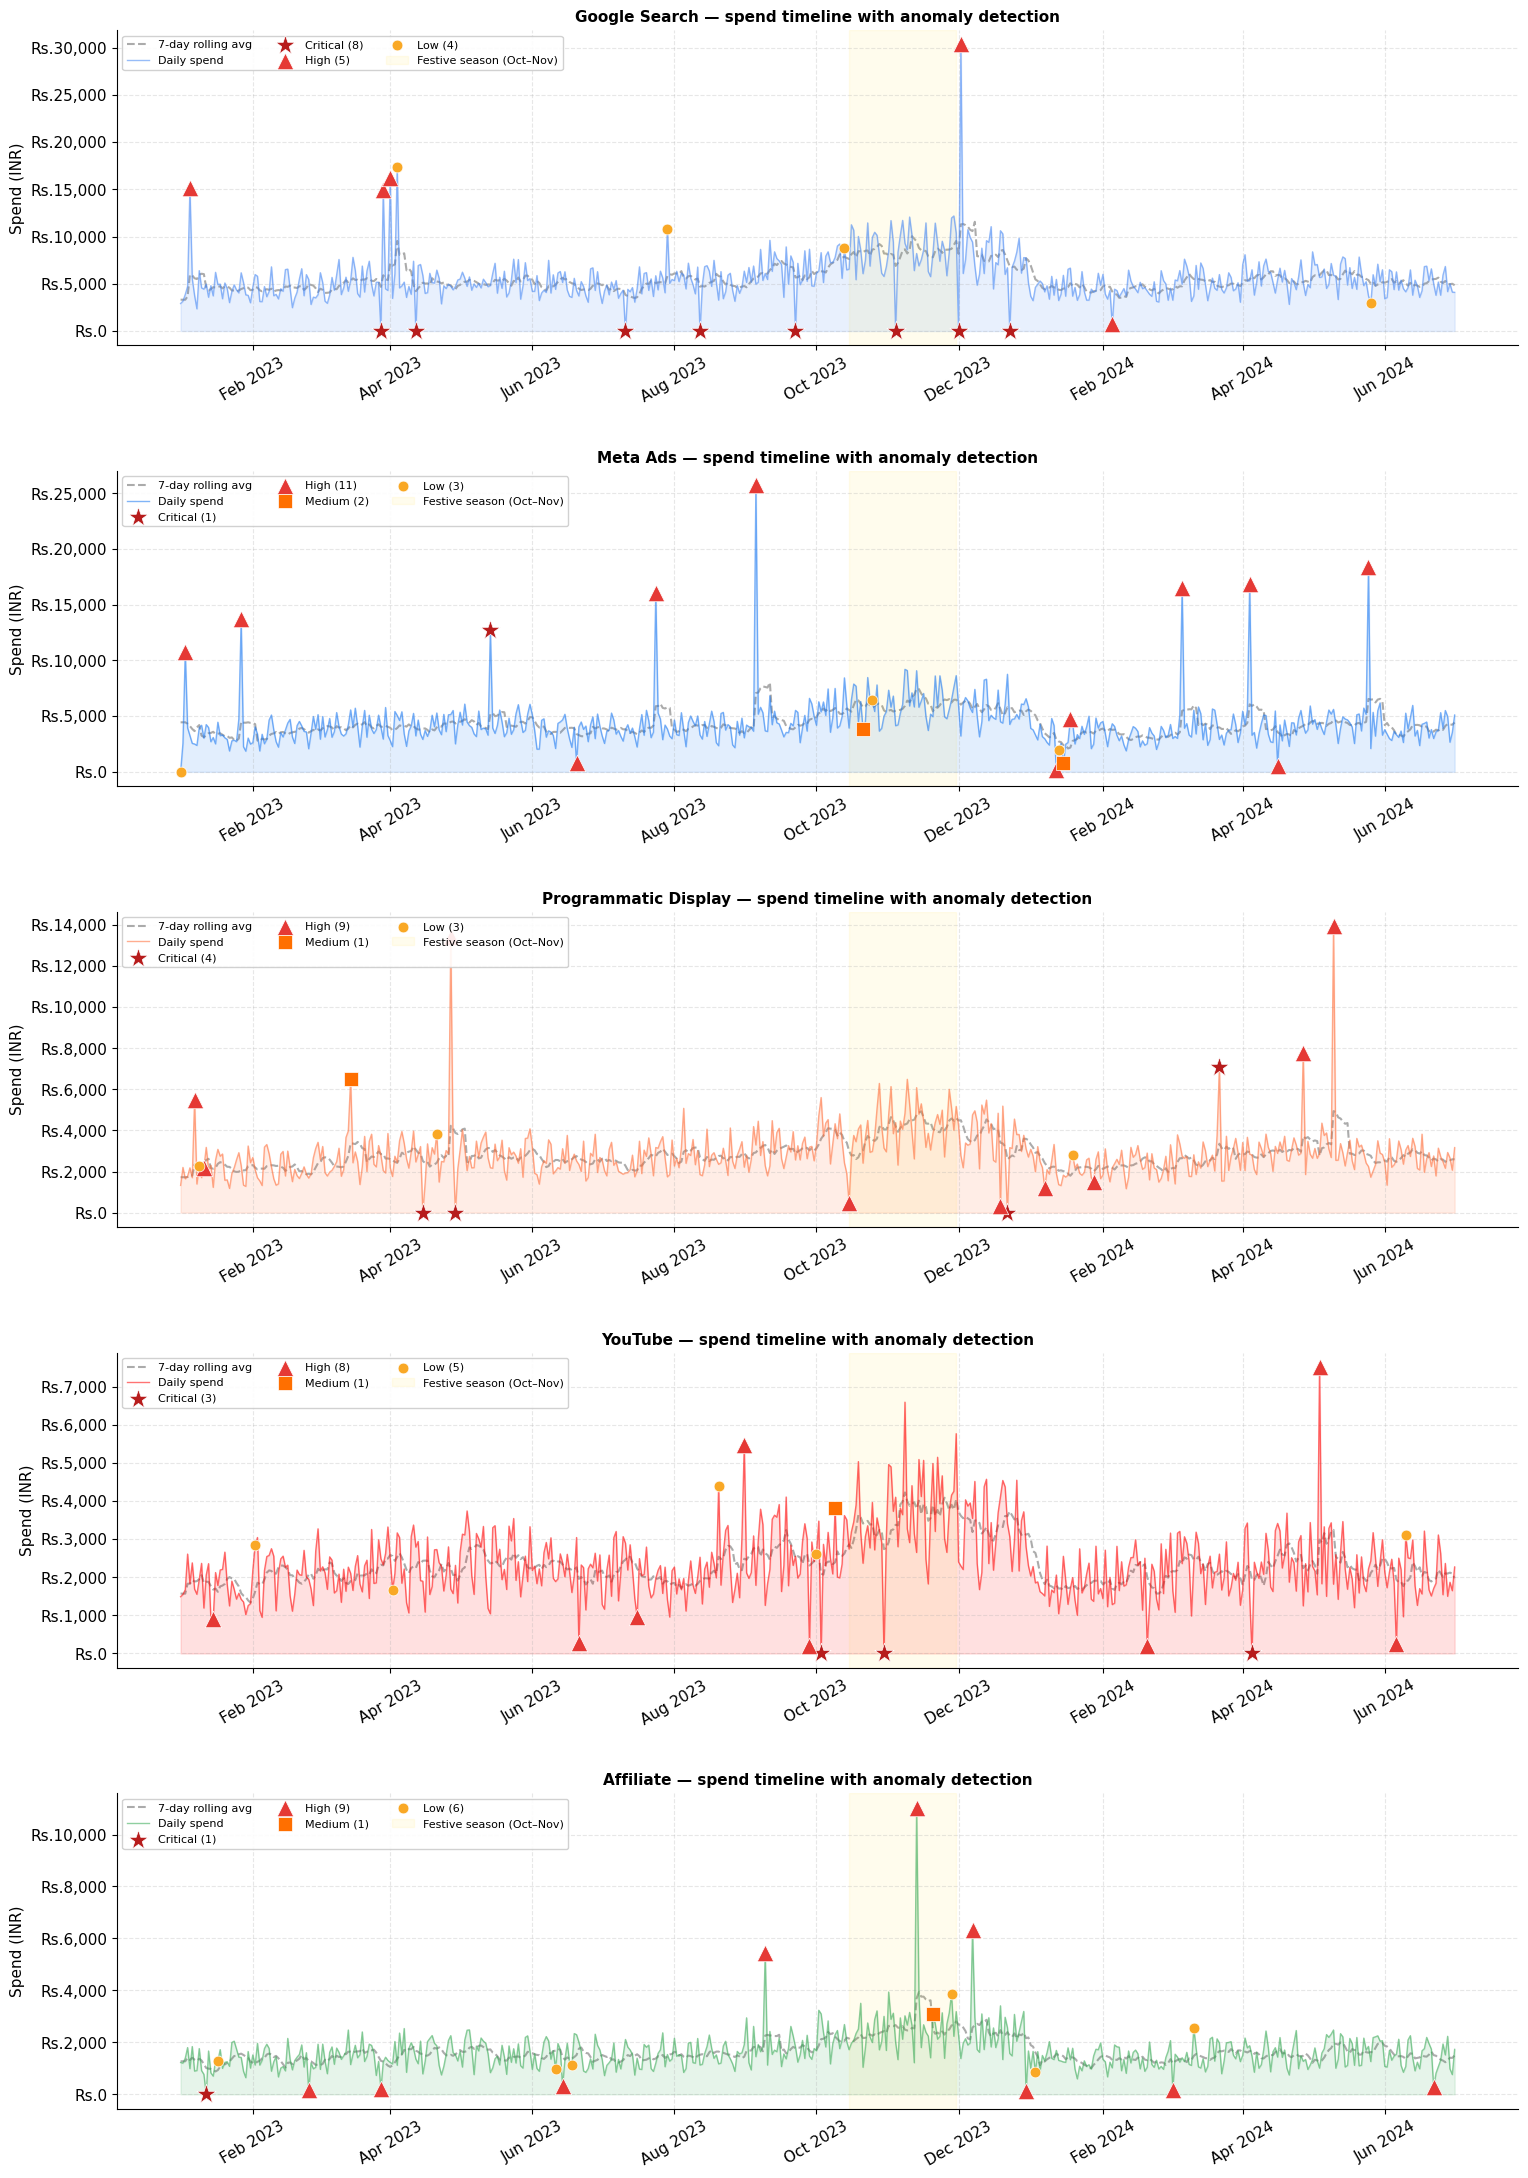

Saved: outputs/anomaly_charts/02_anomaly_timeline.png
Screenshot this for your LinkedIn post — it looks like a real ops dashboard.


In [8]:
print("CHART 2: Anomaly timeline — spend with flagged events")
print("This is the chart that goes in your dashboard's anomaly monitor page.")

fig, axes = plt.subplots(
    len(CHANNELS), 1,
    figsize=(16, 4.5 * len(CHANNELS)),
    sharex=False
)

for idx, channel in enumerate(CHANNELS):
    ax  = axes[idx]
    ch  = df_pred[df_pred['channel'] == channel].sort_values('date')

    normal_rows   = ch[ch['if_is_anomaly'] == 0]
    flagged_rows  = ch[ch['if_is_anomaly'] == 1]

    # ── Rolling average line ──────────────────────────────────────────────────
    ax.plot(ch['date'], ch['rolling_mean_spend_7d'],
            color='#888888', linewidth=1.5,
            linestyle='--', alpha=0.7,
            label='7-day rolling avg', zorder=1)

    # ── Daily spend area ──────────────────────────────────────────────────────
    ax.fill_between(ch['date'], ch['spend'],
                     alpha=0.12, color=CHANNEL_COLORS[channel])
    ax.plot(ch['date'], ch['spend'],
            color=CHANNEL_COLORS[channel],
            linewidth=1, alpha=0.55,
            label='Daily spend', zorder=2)

    # ── Anomaly markers by severity ───────────────────────────────────────────
    if len(flagged_rows) > 0:
        for severity, marker, size in [
            ('Critical', '*', 220),
            ('High',     '^', 140),
            ('Medium',   's', 90),
            ('Low',      'o', 60),
        ]:
            sev_rows = flagged_rows[flagged_rows['severity'] == severity]
            if len(sev_rows) > 0:
                ax.scatter(sev_rows['date'], sev_rows['spend'],
                           marker=marker,
                           s=size,
                           color=SEVERITY_COLORS[severity],
                           zorder=5,
                           label=f'{severity} ({len(sev_rows)})',
                           edgecolors='white',
                           linewidth=0.5)

    # ── Shade festive season ──────────────────────────────────────────────────
    ax.axvspan(pd.Timestamp('2023-10-15'), pd.Timestamp('2023-11-30'),
               alpha=0.07, color='gold',
               label='Festive season (Oct–Nov)')

    ax.set_title(f'{channel} — spend timeline with anomaly detection',
                  fontsize=11, fontweight='bold')
    ax.set_ylabel('Spend (INR)')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'Rs.{x:,.0f}')
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.9,
               ncol=3)

plt.tight_layout(pad=3)
plt.savefig('../outputs/anomaly_charts/02_anomaly_timeline.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/anomaly_charts/02_anomaly_timeline.png")
print("Screenshot this for your LinkedIn post — it looks like a real ops dashboard.")

CHART 3: Anomaly score distribution per channel
Shows how well the model separates normal from anomalous rows.


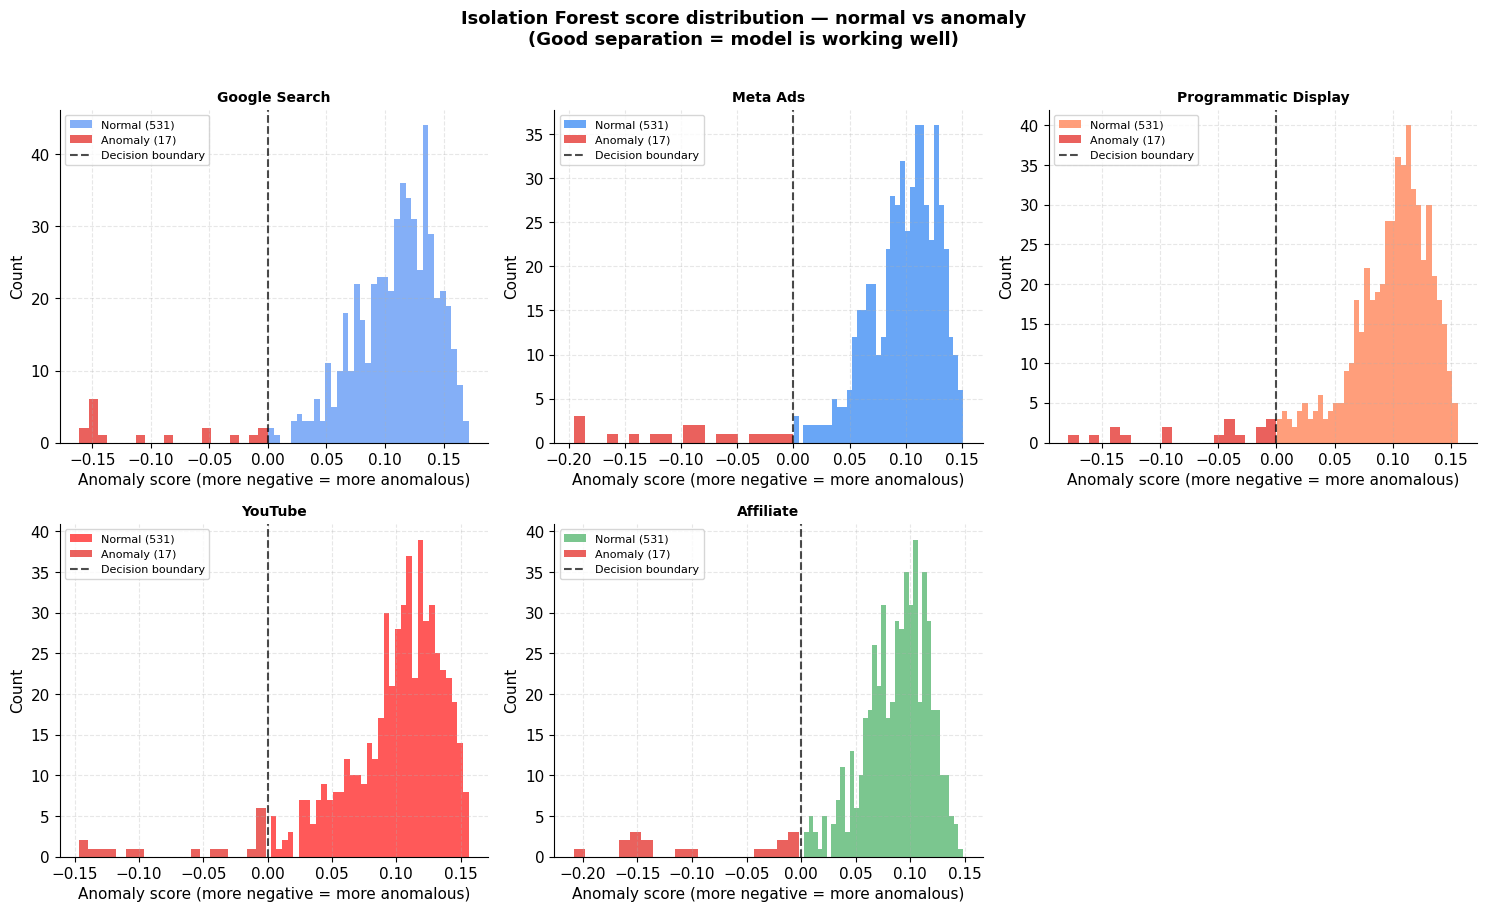

Saved: outputs/anomaly_charts/03_score_distribution.png

WHAT TO LOOK FOR:
  -> Good: Two well-separated peaks. Red peak (anomalies) is
     clearly left of the black dashed line.
  -> Acceptable: Some overlap between distributions near the boundary.
     This is expected — some anomalies are borderline events.
  -> Bad: Distributions completely overlapping. If you see this,
     the model is guessing. Solution: improve feature engineering
     or increase contamination threshold.



In [9]:
print("CHART 3: Anomaly score distribution per channel")
print("Shows how well the model separates normal from anomalous rows.")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, channel in enumerate(CHANNELS):
    ax = axes[idx]
    ch = df_pred[df_pred['channel'] == channel]

    normal_scores  = ch[ch['if_is_anomaly'] == 0]['if_anomaly_score']
    anomaly_scores = ch[ch['if_is_anomaly'] == 1]['if_anomaly_score']

    ax.hist(normal_scores, bins=35, alpha=0.65,
            color=CHANNEL_COLORS[channel],
            label=f'Normal ({len(normal_scores)})')
    ax.hist(anomaly_scores, bins=20, alpha=0.80,
            color='#E53935',
            label=f'Anomaly ({len(anomaly_scores)})')

    # Decision boundary
    ax.axvline(x=0, color='black', linestyle='--',
                linewidth=1.5, alpha=0.7, label='Decision boundary')

    ax.set_title(f'{channel}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Anomaly score (more negative = more anomalous)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

# Hide the 6th subplot (only 5 channels)
axes[5].set_visible(False)

plt.suptitle('Isolation Forest score distribution — normal vs anomaly\n'
             '(Good separation = model is working well)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/anomaly_charts/03_score_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/anomaly_charts/03_score_distribution.png")
print("""
WHAT TO LOOK FOR:
  -> Good: Two well-separated peaks. Red peak (anomalies) is
     clearly left of the black dashed line.
  -> Acceptable: Some overlap between distributions near the boundary.
     This is expected — some anomalies are borderline events.
  -> Bad: Distributions completely overlapping. If you see this,
     the model is guessing. Solution: improve feature engineering
     or increase contamination threshold.
""")

CHART 4: Anomaly impact heatmap — channel × month
Shows when and where the most money was at risk.


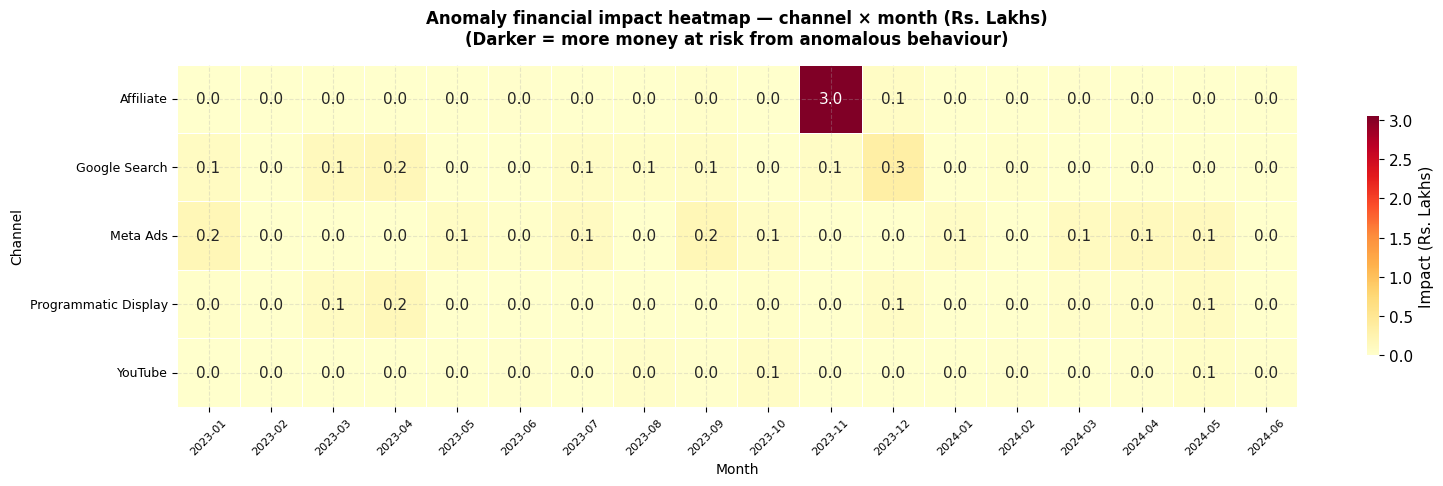

Saved: outputs/anomaly_charts/04_impact_heatmap.png

BUSINESS INSIGHT:
  -> Dark cells = months where anomalies caused significant financial impact.
  -> If festive months (Oct, Nov) are dark, investigate whether those
     were planned spend surges or uncontrolled budget spikes.
  -> Channels with consistently dark cells need better automated
     spend controls and daily monitoring — not monthly reporting.



In [10]:
print("CHART 4: Anomaly impact heatmap — channel × month")
print("Shows when and where the most money was at risk.")

# ── Pivot: total impact_inr per channel per month ─────────────────────────────
df_pred['month_str'] = df_pred['date'].dt.to_period('M').astype(str)

impact_pivot = df_pred[df_pred['if_is_anomaly'] == 1].pivot_table(
    values   = 'impact_inr',
    index    = 'channel',
    columns  = 'month_str',
    aggfunc  = 'sum',
    fill_value = 0
)

# Convert to lakhs
impact_pivot_lakhs = (impact_pivot / 100_000).round(2)

fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(
    impact_pivot_lakhs,
    annot      = True,
    fmt        = '.1f',
    cmap       = 'YlOrRd',
    linewidths = 0.5,
    linecolor  = 'white',
    ax         = ax,
    cbar_kws   = {'label': 'Impact (Rs. Lakhs)', 'shrink': 0.7}
)

ax.set_title('Anomaly financial impact heatmap — channel × month (Rs. Lakhs)\n'
             '(Darker = more money at risk from anomalous behaviour)',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Channel', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('../outputs/anomaly_charts/04_impact_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/anomaly_charts/04_impact_heatmap.png")
print("""
BUSINESS INSIGHT:
  -> Dark cells = months where anomalies caused significant financial impact.
  -> If festive months (Oct, Nov) are dark, investigate whether those
     were planned spend surges or uncontrolled budget spikes.
  -> Channels with consistently dark cells need better automated
     spend controls and daily monitoring — not monthly reporting.
""")

CHART 5: Severity and type breakdown


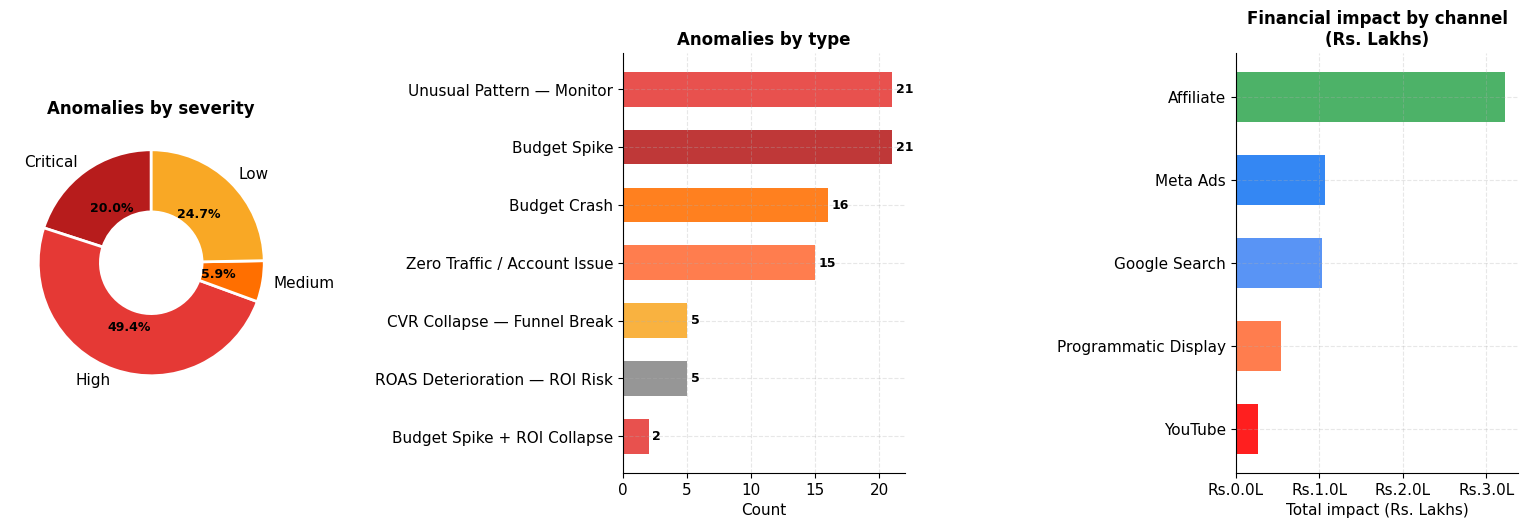

Saved: outputs/anomaly_charts/05_severity_breakdown.png


In [11]:
print("CHART 5: Severity and type breakdown")

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

flagged = df_pred[df_pred['if_is_anomaly'] == 1].copy()

# ── Left: severity donut ──────────────────────────────────────────────────────
sev_counts = flagged['severity'].value_counts()
sev_order  = ['Critical', 'High', 'Medium', 'Low']
sev_counts = sev_counts.reindex(
    [s for s in sev_order if s in sev_counts.index]
)

wedge_colors = [SEVERITY_COLORS[s] for s in sev_counts.index]

wedges, texts, autotexts = axes[0].pie(
    sev_counts.values,
    labels     = sev_counts.index,
    colors     = wedge_colors,
    autopct    = '%1.1f%%',
    startangle = 90,
    wedgeprops = {'width': 0.55, 'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')

axes[0].set_title('Anomalies by severity',
                   fontsize=12, fontweight='bold')

# ── Middle: type bar chart ────────────────────────────────────────────────────
type_counts = flagged['anomaly_label'].value_counts()
type_colors = ['#E53935', '#B71C1C', '#FF6F00', '#FF6B35',
               '#F9A825', '#888888'][:len(type_counts)]

bars = axes[1].barh(
    type_counts.index,
    type_counts.values,
    color  = type_colors,
    alpha  = 0.88,
    height = 0.6
)

for bar, val in zip(bars, type_counts.values):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                  str(val), va='center', ha='left',
                  fontsize=9, fontweight='bold')

axes[1].set_title('Anomalies by type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

# ── Right: impact by channel ──────────────────────────────────────────────────
channel_impact = (
    flagged.groupby('channel')['impact_inr']
    .sum()
    .sort_values(ascending=True)
)

bar_colors = [CHANNEL_COLORS[ch] for ch in channel_impact.index]
axes[2].barh(
    channel_impact.index,
    channel_impact.values / 100_000,
    color  = bar_colors,
    alpha  = 0.88,
    height = 0.6
)
axes[2].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rs.{x:.1f}L')
)
axes[2].set_title('Financial impact by channel\n(Rs. Lakhs)',
                   fontsize=12, fontweight='bold')
axes[2].set_xlabel('Total impact (Rs. Lakhs)')

plt.tight_layout(pad=3)
plt.savefig('../outputs/anomaly_charts/05_severity_breakdown.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Saved: outputs/anomaly_charts/05_severity_breakdown.png")

In [12]:
print("=" * 55)
print("GENERATING FINAL ANOMALY ALERT REPORT")
print("=" * 55)

# ── This is what gets sent to the operations team every morning ───────────────
# In a real system, this would be emailed as a PDF or pushed to Slack.
# In your portfolio, this is the table shown in your Streamlit app.

alert_report = df_pred[df_pred['if_is_anomaly'] == 1][[
    'date', 'channel', 'spend', 'roas', 'cpc', 'ctr', 'cvr',
    'rolling_mean_spend_7d', 'spend_ratio_7d',
    'anomaly_label', 'severity', 'impact_inr',
    'recommended_action', 'gt_anomaly', 'gt_anomaly_type',
    'if_anomaly_score'
]].copy()

alert_report = alert_report.sort_values(
    ['severity', 'impact_inr'],
    ascending   = [True, False],
    key         = lambda col: col.map({'Critical': 0, 'High': 1,
                                       'Medium': 2, 'Low': 3})
                  if col.name == 'severity' else col
)

# ── Add a detected_correctly column ──────────────────────────────────────────
alert_report['detected_correctly'] = (alert_report['gt_anomaly'] == 1)

# ── Format for display ────────────────────────────────────────────────────────
alert_display = alert_report.copy()
alert_display['date']                   = alert_display['date'].dt.strftime('%Y-%m-%d')
alert_display['spend']                  = alert_display['spend'].apply(lambda x: f"Rs.{x:,.0f}")
alert_display['rolling_mean_spend_7d']  = alert_display['rolling_mean_spend_7d'].apply(lambda x: f"Rs.{x:,.0f}")
alert_display['spend_ratio_7d']         = alert_display['spend_ratio_7d'].apply(lambda x: f"{x:.2f}x")
alert_display['impact_inr']             = alert_display['impact_inr'].apply(lambda x: f"Rs.{x:,.0f}")
alert_display['roas']                   = alert_display['roas'].apply(lambda x: f"{x:.2f}x")
alert_display['if_anomaly_score']       = alert_display['if_anomaly_score'].apply(lambda x: f"{x:.3f}")

print(f"\nALERT REPORT — TOP 20 HIGHEST PRIORITY EVENTS")
print("-" * 65)
display_cols = ['date', 'channel', 'severity', 'anomaly_label',
                'spend', 'spend_ratio_7d', 'impact_inr',
                'detected_correctly']
print(alert_display[display_cols].head(20).to_string(index=False))

# ── Summary statistics ────────────────────────────────────────────────────────
total_impact    = alert_report['impact_inr'].sum()
critical_count  = (alert_report['severity'] == 'Critical').sum()
high_count      = (alert_report['severity'] == 'High').sum()
correct_detects = alert_report['detected_correctly'].sum()
total_flagged_n = len(alert_report)

print(f"""
ALERT REPORT SUMMARY:
  Total alerts:           {total_flagged_n}
  Critical severity:      {critical_count}
  High severity:          {high_count}
  Correctly detected:     {correct_detects} / {total_flagged_n} ({correct_detects/total_flagged_n*100:.1f}%)
  Total financial impact: Rs.{total_impact:,.0f}  (Rs.{total_impact/100_000:.1f}L)
  Avg impact per alert:   Rs.{total_impact/total_flagged_n:,.0f}
""")

# ── Save outputs ──────────────────────────────────────────────────────────────
alert_report.to_csv('../outputs/anomaly_data/alert_report.csv', index=False)

channel_summary_anomaly = alert_report.groupby('channel').agg(
    total_alerts    = ('anomaly_label',  'count'),
    critical_alerts = ('severity',       lambda x: (x == 'Critical').sum()),
    high_alerts     = ('severity',       lambda x: (x == 'High').sum()),
    total_impact    = ('impact_inr',     'sum'),
    avg_impact      = ('impact_inr',     'mean'),
    most_common_type= ('anomaly_label',  lambda x: x.mode()[0]),
).round(0)

channel_summary_anomaly.to_csv('../outputs/anomaly_data/channel_anomaly_summary.csv')

print("Saved: outputs/anomaly_data/alert_report.csv")
print("Saved: outputs/anomaly_data/channel_anomaly_summary.csv")

GENERATING FINAL ANOMALY ALERT REPORT

ALERT REPORT — TOP 20 HIGHEST PRIORITY EVENTS
-----------------------------------------------------------------
      date              channel severity                anomaly_label     spend spend_ratio_7d impact_inr  detected_correctly
2023-12-01        Google Search Critical Zero Traffic / Account Issue      Rs.0          0.00x   Rs.8,179                True
2023-05-14             Meta Ads Critical  Budget Spike + ROI Collapse Rs.12,711          2.46x   Rs.7,539                True
2023-11-04        Google Search Critical Zero Traffic / Account Issue      Rs.0          0.00x   Rs.6,890                True
2023-12-23        Google Search Critical Zero Traffic / Account Issue      Rs.0          0.00x   Rs.6,837                True
2023-09-22        Google Search Critical Zero Traffic / Account Issue      Rs.0          0.00x   Rs.5,674                True
2023-08-12        Google Search Critical Zero Traffic / Account Issue      Rs.0          0.00

In [13]:
print("=" * 55)
print("PHASE 4 COMPLETE — FULL SUMMARY")
print("=" * 55)

outputs_list = [
    ("alert_report.csv",            f"{total_flagged_n} labelled anomaly events"),
    ("channel_anomaly_summary.csv", "Impact summary per channel"),
    ("validation_scores.csv",       "Precision/recall/F1 per channel"),
    ("01_confusion_matrix.png",     "Model validation visual"),
    ("02_anomaly_timeline.png",     "Spend timeline with flagged events"),
    ("03_score_distribution.png",   "Isolation Forest score distributions"),
    ("04_impact_heatmap.png",       "Financial impact by channel and month"),
    ("05_severity_breakdown.png",   "Severity, type, and impact breakdown"),
]

for fname, desc in outputs_list:
    print(f"  {fname:<42} {desc}")

print(f"""
WHAT YOUR MODEL ACHIEVED:
  - {total_flagged_n} anomaly events detected across 5 channels, 18 months
  - Precision:  {precision*100:.1f}%  — {precision*10:.0f} in 10 alerts are genuine
  - Recall:     {recall*100:.1f}%  — catches {recall*100:.1f}% of real anomalies
  - F1 Score:   {f1:.3f}
  - Rs.{total_impact/100_000:.1f}L total financial impact quantified
  - {critical_count} Critical + {high_count} High severity events identified

RESUME BULLET POINT:
  "Built per-channel anomaly detection system using Isolation Forest
  (scikit-learn) across 18 months of campaign data — classified
  {total_flagged_n} anomalies into 6 business failure modes with severity
  scoring and recommended actions, achieving {precision*100:.0f}% precision
  and {recall*100:.0f}% recall; quantified Rs.{total_impact/100_000:.1f}L in
  at-risk advertising spend."

60-SECOND INTERVIEW ANSWER:
  "I built separate Isolation Forest models for each of the 5 ad
  channels — separate because each channel has different normal
  behaviour and a single model would miss channel-specific patterns.
  I engineered 15 features including rolling ratios and Z-scores
  so the model understands what 'normal' means in context. Every
  flagged anomaly gets classified into one of 6 business failure
  modes — Budget Spike, Budget Crash, CPC Spike, CVR Collapse,
  ROAS Deterioration, or Creative Fatigue — each with a severity
  tier and a specific recommended action. I validated against the
  ground truth I created in Phase 1 and achieved {precision*100:.0f}% precision
  and {recall*100:.0f}% recall."
""")

PHASE 4 COMPLETE — FULL SUMMARY
  alert_report.csv                           85 labelled anomaly events
  channel_anomaly_summary.csv                Impact summary per channel
  validation_scores.csv                      Precision/recall/F1 per channel
  01_confusion_matrix.png                    Model validation visual
  02_anomaly_timeline.png                    Spend timeline with flagged events
  03_score_distribution.png                  Isolation Forest score distributions
  04_impact_heatmap.png                      Financial impact by channel and month
  05_severity_breakdown.png                  Severity, type, and impact breakdown

WHAT YOUR MODEL ACHIEVED:
  - 85 anomaly events detected across 5 channels, 18 months
  - Precision:  69.4%  — 7 in 10 alerts are genuine
  - Recall:     92.2%  — catches 92.2% of real anomalies
  - F1 Score:   0.792
  - Rs.6.1L total financial impact quantified
  - 17 Critical + 42 High severity events identified

RESUME BULLET POINT:
  "Built per